In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
# 1. Define Fuzzy Variables ------------------------------------------------

# Input 1: Distance (meters)
distance = ctrl.Antecedent(np.arange(0, 81, 1), 'distance')
# Input 2: Relative Speed (km/h)
rel_speed = ctrl.Antecedent(np.arange(-30, 31, 1), 'rel_speed')
# Input 3: Road Slope (degrees)
slope = ctrl.Antecedent(np.arange(-8, 9, 1), 'slope')
# Output: Acceleration Command (m/s^2)
acc_cmd = ctrl.Consequent(np.arange(-2, 2.1, 0.1), 'acc_cmd')

In [3]:
# 2. Define Membership Functions ------------------------------------------

# Distance
distance['close']  = fuzz.trimf(distance.universe, [0, 0, 15])
distance['medium'] = fuzz.trimf(distance.universe, [10, 25, 40])
distance['far']    = fuzz.trimf(distance.universe, [35, 80, 80])

# Relative Speed
rel_speed['approaching'] = fuzz.trimf(rel_speed.universe, [-30, -30, -5])
rel_speed['stable']      = fuzz.trimf(rel_speed.universe, [-10, 0, 10])
rel_speed['receding']    = fuzz.trimf(rel_speed.universe, [5, 30, 30])

# Road Slope
slope['downhill'] = fuzz.trimf(slope.universe, [-8, -8, -2])
slope['flat']     = fuzz.trimf(slope.universe, [-3, 0, 3])
slope['uphill']   = fuzz.trimf(slope.universe, [2, 8, 8])

In [4]:
# Acceleration Command
acc_cmd['strong_decelerate'] = fuzz.trimf(acc_cmd.universe, [-2, -2, -1])
acc_cmd['decelerate']        = fuzz.trimf(acc_cmd.universe, [-1.5, -0.8, -0.3])
acc_cmd['maintain']          = fuzz.trimf(acc_cmd.universe, [-0.5, 0, 0.5])
acc_cmd['accelerate']        = fuzz.trimf(acc_cmd.universe, [0.3, 0.8, 1.5])
acc_cmd['strong_accelerate'] = fuzz.trimf(acc_cmd.universe, [1, 2, 2])

In [5]:
# 3. Define Rule Base -------------------------------------------------------

rule1 = ctrl.Rule(distance['close'] & rel_speed['approaching'] & slope['flat'], acc_cmd['strong_decelerate'])
rule2 = ctrl.Rule(distance['medium'] & rel_speed['approaching'] & slope['flat'], acc_cmd['decelerate'])
rule3 = ctrl.Rule(distance['far'] & rel_speed['approaching'] & slope['flat'], acc_cmd['maintain'])
rule4 = ctrl.Rule(distance['far'] & rel_speed['receding'] & slope['flat'], acc_cmd['accelerate'])
rule5 = ctrl.Rule(distance['medium'] & rel_speed['stable'] & slope['flat'], acc_cmd['maintain'])
rule6 = ctrl.Rule(distance['close'] & rel_speed['stable'] & slope['uphill'], acc_cmd['decelerate'])
rule7 = ctrl.Rule(distance['medium'] & rel_speed['approaching'] & slope['downhill'], acc_cmd['strong_decelerate'])
rule8 = ctrl.Rule(distance['far'] & rel_speed['receding'] & slope['uphill'], acc_cmd['strong_accelerate'])
rule9 = ctrl.Rule(distance['medium'] & rel_speed['stable'] & slope['downhill'], acc_cmd['decelerate'])

In [6]:
# 4. Build and Simulate System ---------------------------------------------

acc_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9])
acc_sim = ctrl.ControlSystemSimulation(acc_ctrl)


In [7]:
# Example input: Distance=12m, Relative Speed=-8km/h, Slope=-4 degrees (downhill)
acc_sim.input['distance'] = 12
acc_sim.input['rel_speed'] = -8
acc_sim.input['slope'] = -4

acc_sim.compute()
print('Acceleration Command:', acc_sim.output['acc_cmd'])

Acceleration Command: -1.1475834022608213


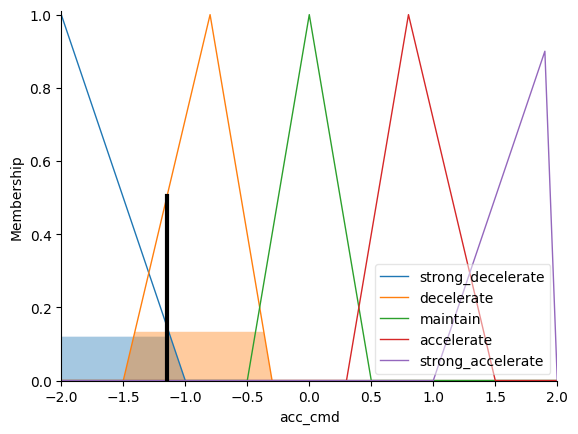

In [9]:
# You can plot the output membership functions if needed
acc_cmd.view(sim=acc_sim)